[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch16.ipynb)

Notebook Bab 16 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal yang Anda kerjakan sendiri.

Demo memakai audit fitur otomatis yang sudah dibekukan dari snapshot UCI Online Retail: unitnya pelanggan pada `index_time`, targetnya `future_active_60d`, dan kandidat fiturnya dinilai dengan delta-CV. Tidak ada instalasi `featuretools` atau unduhan data saat notebook dijalankan.


## Persiapan


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


## Section 1 - Demo: Kandidat Otomatis + Kurasi Manusia


## Data: audit fitur dari Online Retail

Bab ini memakai tabel pelanggan/cutoff dari Bab 6. Mesin membangkitkan kandidat transformasi, rasio, kalender, identifier, dan fitur masa depan. Manusia lalu memutuskan mana yang diterima, ditinjau ulang, atau ditolak.


In [2]:
DATA_DIR = section_data_dir('ch16_online_retail')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))
summary = pd.read_csv(DATA_DIR / 'autofe_summary_metrics.csv')
candidates = pd.read_csv(DATA_DIR / 'autofe_candidate_scores.csv')
audit_matrix = pd.read_parquet(DATA_DIR / 'autofe_feature_matrix.parquet')

print(f"Baris audit: {stats['rows']} | train={stats['train_rows']} | holdout={stats['test_rows']}")
print(f"Target: {stats['target']} | rate={stats['target_rate_all']:.3f}")
print(f"Kandidat otomatis: {stats['candidate_count']} | diterima manusia: {stats['accepted_candidate_count']}")
print('Fixed ruler:', stats['fixed_ruler'])
audit_matrix[['CustomerID', 'index_time', 'future_active_60d', 'invoice_count_90d', 'gross_value_90d', 'days_since_last_invoice']].head()


Baris audit: 20603 | train=13602 | holdout=7001
Target: future_active_60d | rate=0.428
Kandidat otomatis: 15 | diterima manusia: 6
Fixed ruler: SimpleImputer + StandardScaler + LogisticRegression(class_weight='balanced')


,CustomerID,index_time,future_active_60d,invoice_count_90d,gross_value_90d,days_since_last_invoice
0,12346,2011-04-01,0,2.0,77183.60,72
1,12347,2011-04-01,1,1.0,475.39,64
2,12348,2011-04-01,1,1.0,227.44,65
3,12350,2011-04-01,0,1.0,334.40,57
4,12352,2011-04-01,0,8.0,1561.81,9


## Delta-CV: baseline, kandidat terkurasi, dan kebocoran


                representation  feature_count  cv_roc_auc  cv_delta_vs_base  holdout_roc_auc  holdout_delta_vs_base                                                  fold_scores
               base_manual_90d              5      0.7278            0.0000           0.7162                 0.0000 [0.7248216952521381, 0.7260069272450033, 0.7324563165294236]
       curated_auto_candidates             12      0.7297            0.0019           0.7215                 0.0053  [0.7248314172830704, 0.730655684887469, 0.7335328789077391]
broad_nonleaky_auto_candidates             19      0.7296            0.0019           0.7202                 0.0040    [0.72324888669243, 0.732950021360819, 0.7326829828135312]
    unsafe_with_future_leakage             21      0.9997            0.2719           1.0000                 0.2838                               [1.0, 0.9991209656320271, 1.0]


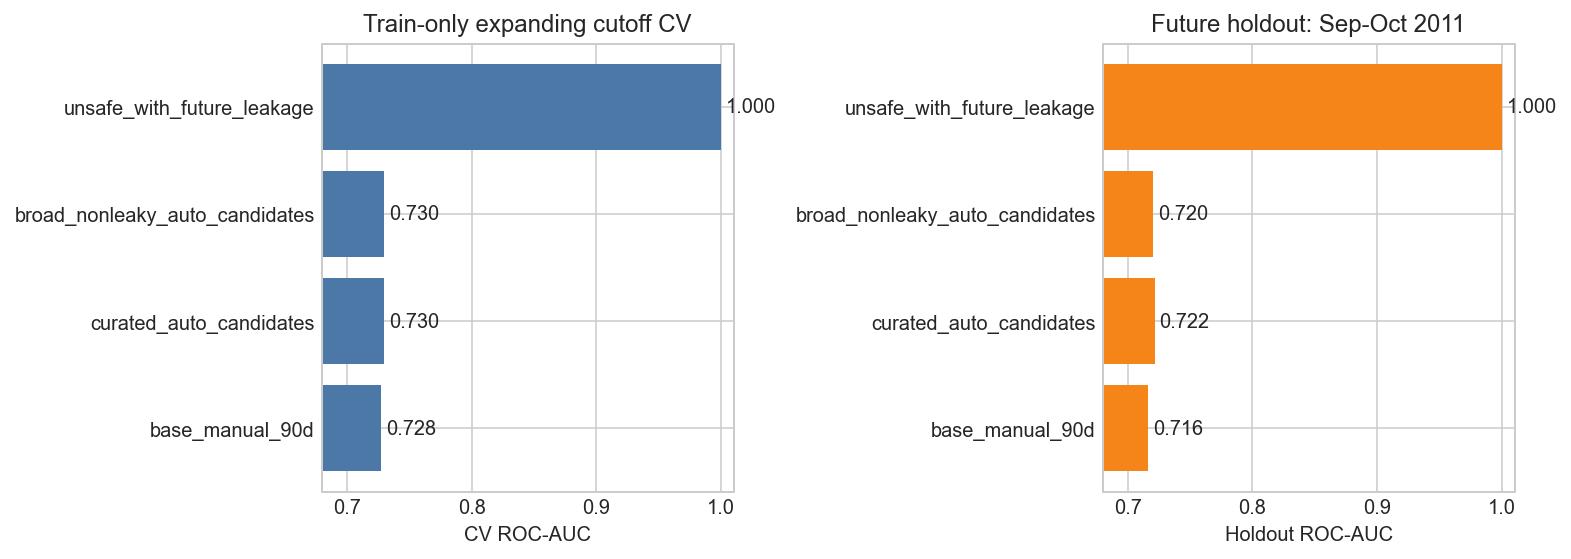

In [3]:
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

plot_df = summary.copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].barh(plot_df['representation'], plot_df['cv_roc_auc'], color='#4c78a8')
axes[0].set_xlim(0.68, 1.01)
axes[0].set_xlabel('CV ROC-AUC')
axes[0].set_title('Train-only expanding cutoff CV')
for i, value in enumerate(plot_df['cv_roc_auc']):
    axes[0].text(value + 0.004, i, f'{value:.3f}', va='center')

axes[1].barh(plot_df['representation'], plot_df['holdout_roc_auc'], color='#f58518')
axes[1].set_xlim(0.68, 1.01)
axes[1].set_xlabel('Holdout ROC-AUC')
axes[1].set_title('Future holdout: Sep-Oct 2011')
for i, value in enumerate(plot_df['holdout_roc_auc']):
    axes[1].text(value + 0.004, i, f'{value:.3f}', va='center')
plt.tight_layout()
plt.show()


## Audit kandidat: skor bukan keputusan akhir


                    candidate      family       decision  cv_delta_vs_base  holdout_delta_vs_base                                                                  reason
 future_positive_invoices_60d     leakage reject_leakage           +0.2722                +0.2838             Directly counts the future event used to define the target.
       future_gross_value_60d     leakage reject_leakage           +0.2700                +0.2818     Uses the future label window and is unavailable at prediction time.
log1p_days_since_last_invoice   transform         accept           +0.0005                +0.0012      Row-wise monotonic transform of a known-at-cutoff recency feature.
  recency_weighted_gross_180d aggregation         accept           +0.0005                +0.0002 Summarizes older transactions with recency weighting before the cutoff.
     gross_per_active_day_90d       ratio         accept           +0.0004                -0.0002        Normalizes 90-day value by the number of acti

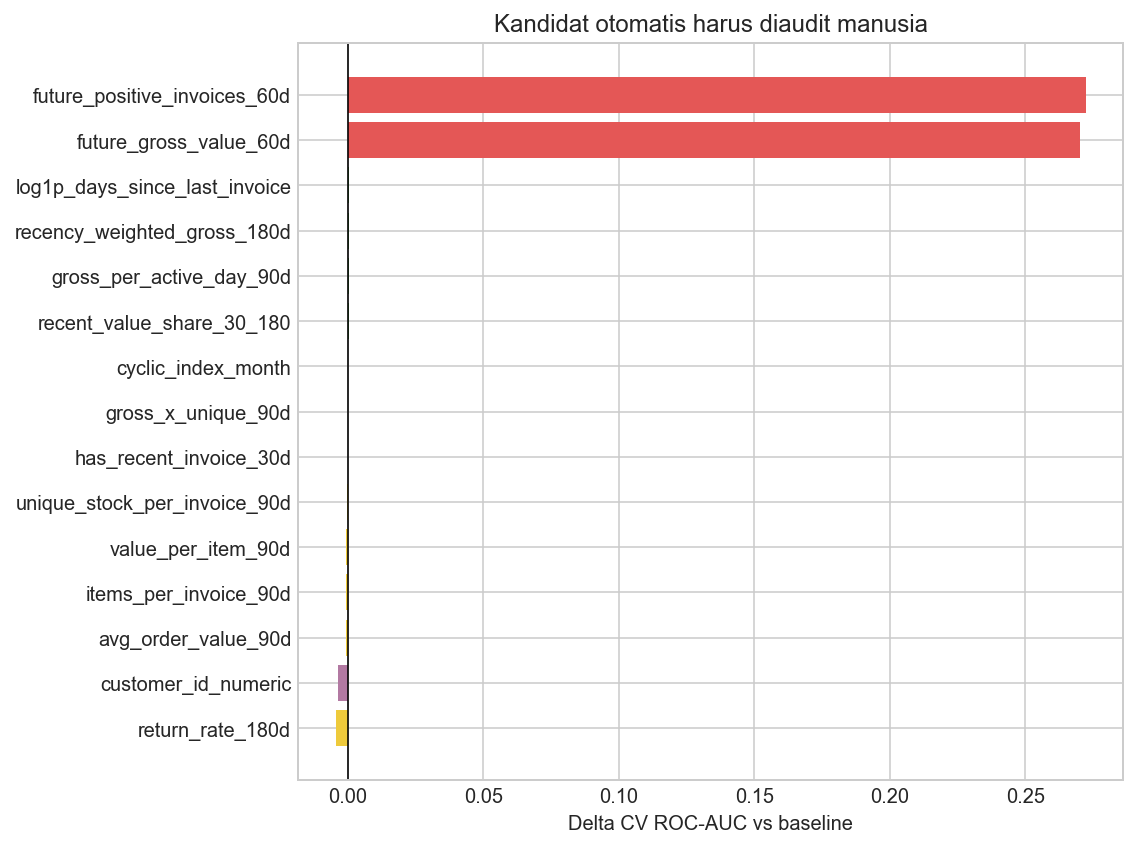

In [4]:
view_cols = ['candidate', 'family', 'decision', 'cv_delta_vs_base', 'holdout_delta_vs_base', 'reason']
print(candidates[view_cols].head(12).to_string(index=False, float_format=lambda x: f'{x:+.4f}'))

color_map = {
    'accept': '#54a24b',
    'review': '#eeca3b',
    'reject_semantic': '#b279a2',
    'reject_leakage': '#e45756',
}
plot_df = candidates.sort_values('cv_delta_vs_base')
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_df['candidate'], plot_df['cv_delta_vs_base'], color=plot_df['decision'].map(color_map))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Delta CV ROC-AUC vs baseline')
ax.set_title('Kandidat otomatis harus diaudit manusia')
plt.tight_layout()
plt.show()


> ?? **Amati.** Kandidat terkurasi memberi kenaikan kecil tetapi nyata pada holdout masa depan. Kandidat yang memakai jendela masa depan terlihat hampir sempurna, justru karena bocor. `customer_id_numeric` juga ditolak walaupun bisa dihitung, karena ID bukan besaran numerik. Di Bab 16, skor adalah bahan audit; keputusan akhir tetap menggabungkan validasi, ketersediaan saat inferensi, dan makna domain.


## Section 2 - Mini Project

## Soal

Gunakan tabel audit yang sama untuk membuat keputusan kurasi fitur otomatis.

Tugas:

1. Pilih 5-8 kandidat dari `mini_candidates` yang menurut Anda layak masuk tahap berikutnya.
2. Pisahkan alasan penolakan menjadi minimal dua kategori: bocor dan tidak bermakna secara semantik.
3. Tulis ringkasan 3-4 kalimat: apakah Anda akan menerima kandidat berdasarkan skor saja, atau perlu aturan manusia tambahan?

**Luaran:** daftar kandidat diterima/ditolak, alasan singkat, dan ringkasan keputusan.

**Kriteria penilaian:** (a) fitur masa depan ditolak; (b) identifier tidak diperlakukan sebagai angka biasa; (c) keputusan menyebut metric sekaligus makna fitur.


In [5]:
# DATA AWAL (jangan diubah)
mini_candidates = candidates.copy()
mini_matrix = audit_matrix.copy()

print('Kandidat tersedia:', len(mini_candidates))
mini_candidates[['candidate', 'family', 'decision', 'cv_delta_vs_base', 'holdout_delta_vs_base']].head(10)


Kandidat tersedia: 15


,candidate,family,decision,cv_delta_vs_base,holdout_delta_vs_base
0,future_positive_invoices_60d,leakage,reject_leakage,0.272238,0.283773
1,future_gross_value_60d,leakage,reject_leakage,0.270015,0.281773
2,log1p_days_since_last_invoice,transform,accept,0.000528,0.001205
3,recency_weighted_gross_180d,aggregation,accept,0.000519,0.000165
4,gross_per_active_day_90d,ratio,accept,0.000392,-0.000175
5,recent_value_share_30_180,ratio,accept,0.000253,0.003316
6,cyclic_index_month,calendar,accept,0.000106,0.000381
7,gross_x_unique_90d,interaction,review,0.000071,0.000059
8,has_recent_invoice_30d,threshold,accept,0.000023,0.000624
9,unique_stock_per_invoice_90d,ratio,review,-0.000522,-0.000411


In [6]:
# Kerjakan di sini.
# Petunjuk: mulai dari mini_candidates, kelompokkan berdasarkan decision/family,
# lalu jelaskan mana yang Anda terima, tinjau ulang, atau tolak.
